# Setup

In [23]:
import pydicom
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio
from pathlib import Path

In [24]:
PET_PATH = Path('data/02324177_s2_e_1_BRAIN_DINAMIC_COLINA_AC_FORISI260916')
MR_PATH  = Path('data/15252129_s1_AX_3D_T1__C_FSPGR_FORISI260916')

pet_ds = pydicom.dcmread(PET_PATH)
mr_ds  = pydicom.dcmread(MR_PATH)

# Task 1C - Rearrange the Pixel Array

## Metadata Overview

In [25]:
keys = ['NumberOfFrames', 'Rows', 'Columns', 'SpacingBetweenSlices', 'PixelSpacing', [0x0055, 0x1001], [0x0055, 0x1004], [0x0055, 0x1002]]
for key in keys:
    print(pet_ds[key])

(0028,0008) Number of Frames                    IS: '1692'
(0028,0010) Rows                                US: 256
(0028,0011) Columns                             US: 256
(0018,0088) Spacing Between Slices              DS: '3.27'
(0028,0030) Pixel Spacing                       DS: [1.171875, 1.171875]
(0055,1001) [Frame Start Times Vector]          FD: Array of 36 elements
(0055,1004) [Frame Durations (ms) Vector]       FD: Array of 36 elements
(0055,1002) [Frame Positions Vector]            FD: Array of 5076 elements


## Temporal Structure

In [26]:
frame_start_times =  np.array(pet_ds[0x0055, 0x1001].value)

unique_t = np.unique(frame_start_times)
n_time   = len(unique_t)

print(f'Number of time frames: {n_time}')
print(f'Time points (s): {unique_t}')

Number of time frames: 36
Time points (s): [   0.    5.   10.   15.   20.   25.   30.   35.   40.   45.   50.   60.
   70.   80.   90.  110.  130.  150.  180.  210.  240.  270.  300.  360.
  420.  480.  540.  600.  750.  900. 1051. 1201. 1501. 1801. 2101. 2401.]


## Spatial Structure

In [27]:

frame_positions = np.array(pet_ds[0x0055, 0x1002].value).reshape(pet_ds['NumberOfFrames'].value,3)

flat_z = frame_positions[:,2]
unique_z = np.unique(flat_z)

n_slices = len(unique_z)

print(f'Number of slices: {n_slices}')
print(f'Total frames: {n_time} time × {n_slices} slices = {n_time * n_slices}')

Number of slices: 47
Total frames: 36 time × 47 slices = 1692


In [28]:
pixel_array = pet_ds.pixel_array
print(f'Pixel array shape: {pixel_array.shape}')

for i in range(10):
    print(f' {i} | {flat_z[i]:.2f} | TF: {i // n_slices} | Slice: {i % n_slices}')

for i in [44, 45, 46, 47, 48, 49]:
    print(f' {i} | {flat_z[i]:.2f} | TF: {i // n_slices} | Slice: {i % n_slices}')


Pixel array shape: (1692, 256, 256)
 0 | -170.42 | TF: 0 | Slice: 0
 1 | -167.15 | TF: 0 | Slice: 1
 2 | -163.88 | TF: 0 | Slice: 2
 3 | -160.61 | TF: 0 | Slice: 3
 4 | -157.34 | TF: 0 | Slice: 4
 5 | -154.07 | TF: 0 | Slice: 5
 6 | -150.80 | TF: 0 | Slice: 6
 7 | -147.53 | TF: 0 | Slice: 7
 8 | -144.26 | TF: 0 | Slice: 8
 9 | -140.99 | TF: 0 | Slice: 9
 44 | -26.54 | TF: 0 | Slice: 44
 45 | -23.27 | TF: 0 | Slice: 45
 46 | -20.00 | TF: 0 | Slice: 46
 47 | -170.42 | TF: 1 | Slice: 0
 48 | -167.15 | TF: 1 | Slice: 1
 49 | -163.88 | TF: 1 | Slice: 2


## Index Map

In [29]:
slice_idx = np.searchsorted(unique_z, flat_z)
print('slice_idx', slice_idx[40:50])
print('slice_idx_len', len(slice_idx))

time_idx = np.arange(len(flat_z)) // n_slices
print('time_idx', time_idx[40:50])
print('time_idx shape:', len(time_idx))

frame_index = np.empty((n_time, n_slices), dtype=int)
for i in range(pixel_array.shape[0]):
    frame_index[time_idx[i], slice_idx[i]] = i

print(f'frame_index shape: {frame_index.shape}')
print(f'frame_index[0, :5] = {frame_index[0, :5]}')


slice_idx [40 41 42 43 44 45 46  0  1  2]
slice_idx_len 1692
time_idx [0 0 0 0 0 0 0 1 1 1]
time_idx shape: 1692
frame_index shape: (36, 47)
frame_index[0, :5] = [0 1 2 3 4]


## Assemble Pixel Array

In [30]:
rows = int(pet_ds.Rows)
cols = int(pet_ds.Columns)

# pet4d_loop = np.empty((n_time, n_slices, rows, cols), dtype=pixel_array.dtype)
# for t in range(n_time):
#     for s in range(n_slices):
#         pet4d_loop[t, s] = pixel_array[frame_index[t, s]]

pet4d = pixel_array[frame_index] 

print(f'pet4d shape: {pet4d.shape}') 

pet4d shape: (36, 47, 256, 256)


## Validation


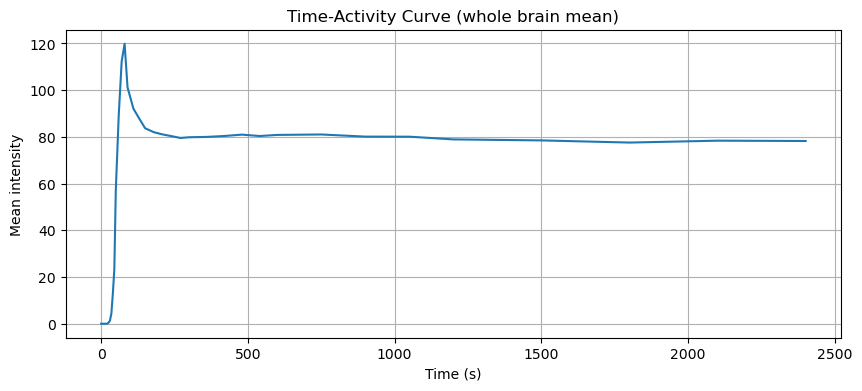

All-zero time frames: [0 1 2 3]


In [31]:
mean_per_frame = np.mean(pet4d, axis=(1,2,3))

plt.figure(figsize=(10, 4))
plt.plot(unique_t, mean_per_frame)
plt.xlabel('Time (s)')
plt.ylabel('Mean intensity')
plt.title('Time-Activity Curve (whole brain mean)')
plt.grid(True)
plt.show()

zero_frames = np.where(mean_per_frame == 0)[0]
print(f'All-zero time frames: {zero_frames}')

# Task 1D - Visualize the Last Frame

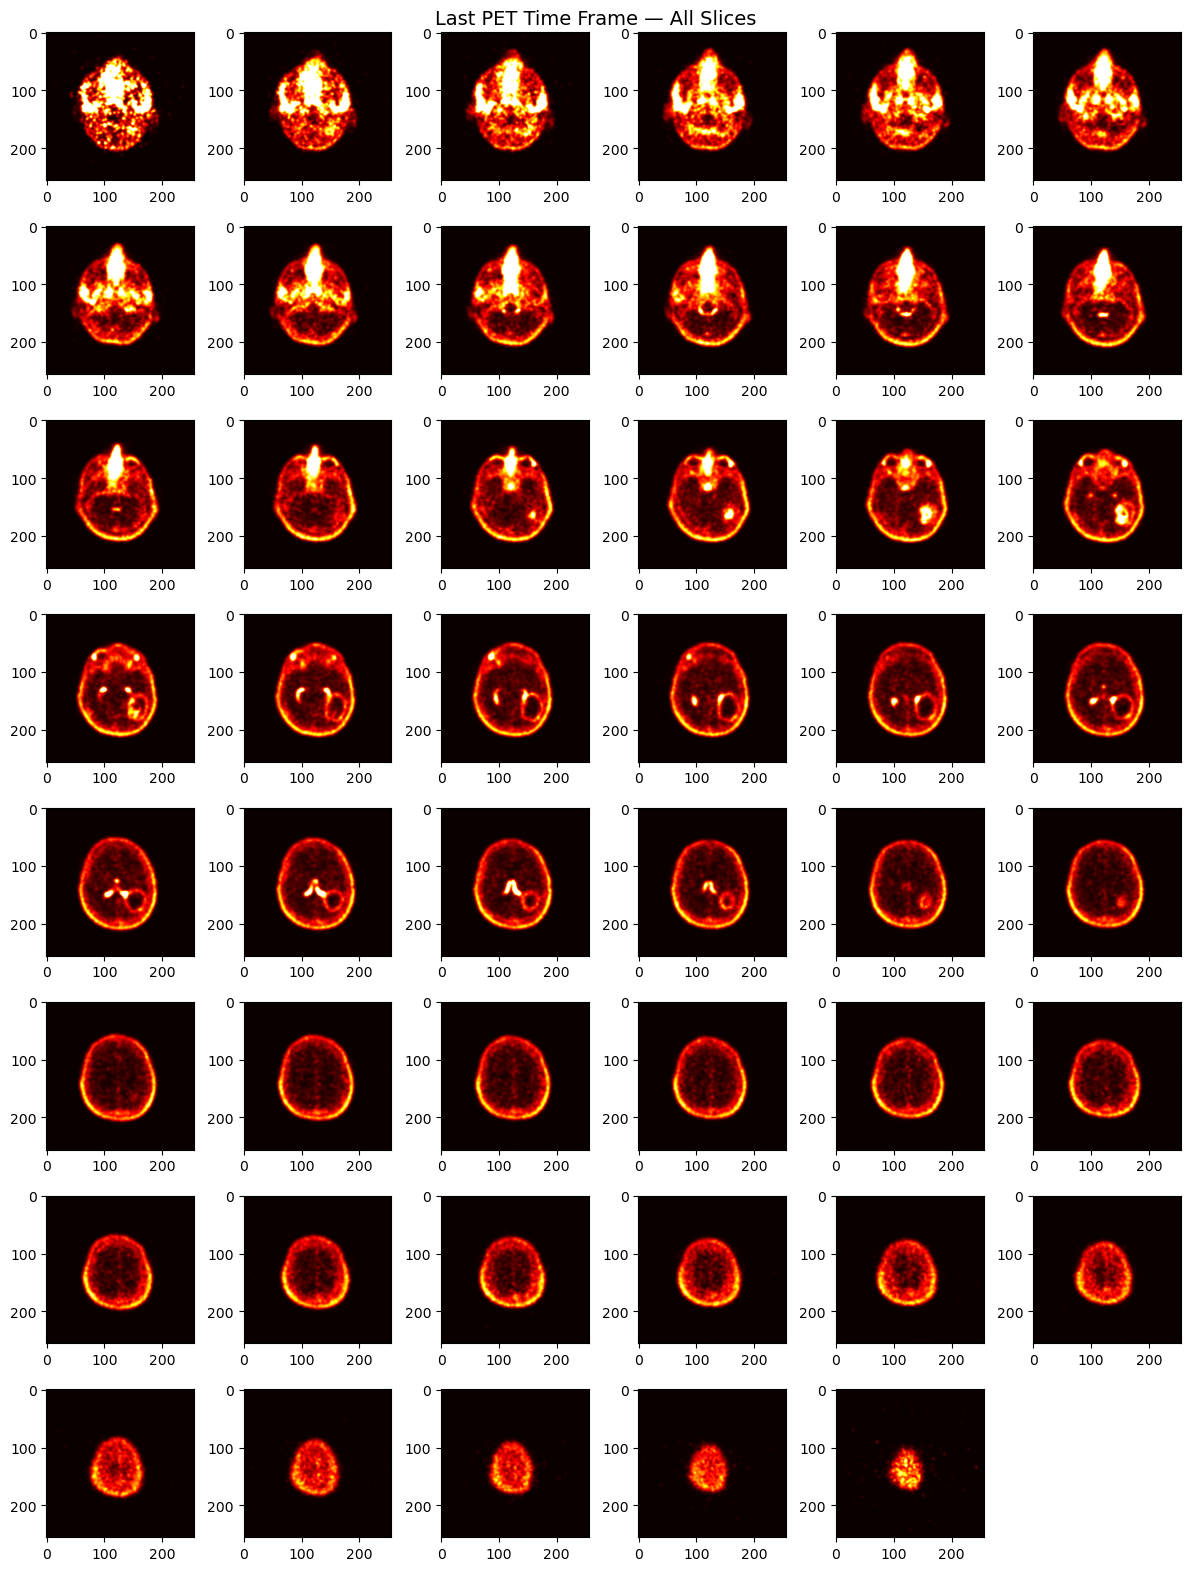

In [32]:
last_frame = pet4d[-1]  # shape: (47, 256, 256)

vmax = np.percentile(last_frame, 99)
vmin = 0

n_cols = 6
n_rows = int(np.ceil(n_slices / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2, n_rows * 2))
fig.suptitle('Last PET Time Frame — All Slices', fontsize=14)

for i, ax in enumerate(axes.flat):
    if i < n_slices:
        ax.imshow(last_frame[i], cmap='hot', vmin=vmin, vmax=vmax)
        pass
    else:
        ax.axis('off')

plt.tight_layout()
plt.savefig('./results_task1/last_frame.png', dpi=100, bbox_inches='tight')
plt.show()

# Task 1D - Visualize the Mean Frame

mean_pet shape: (47, 256, 256)


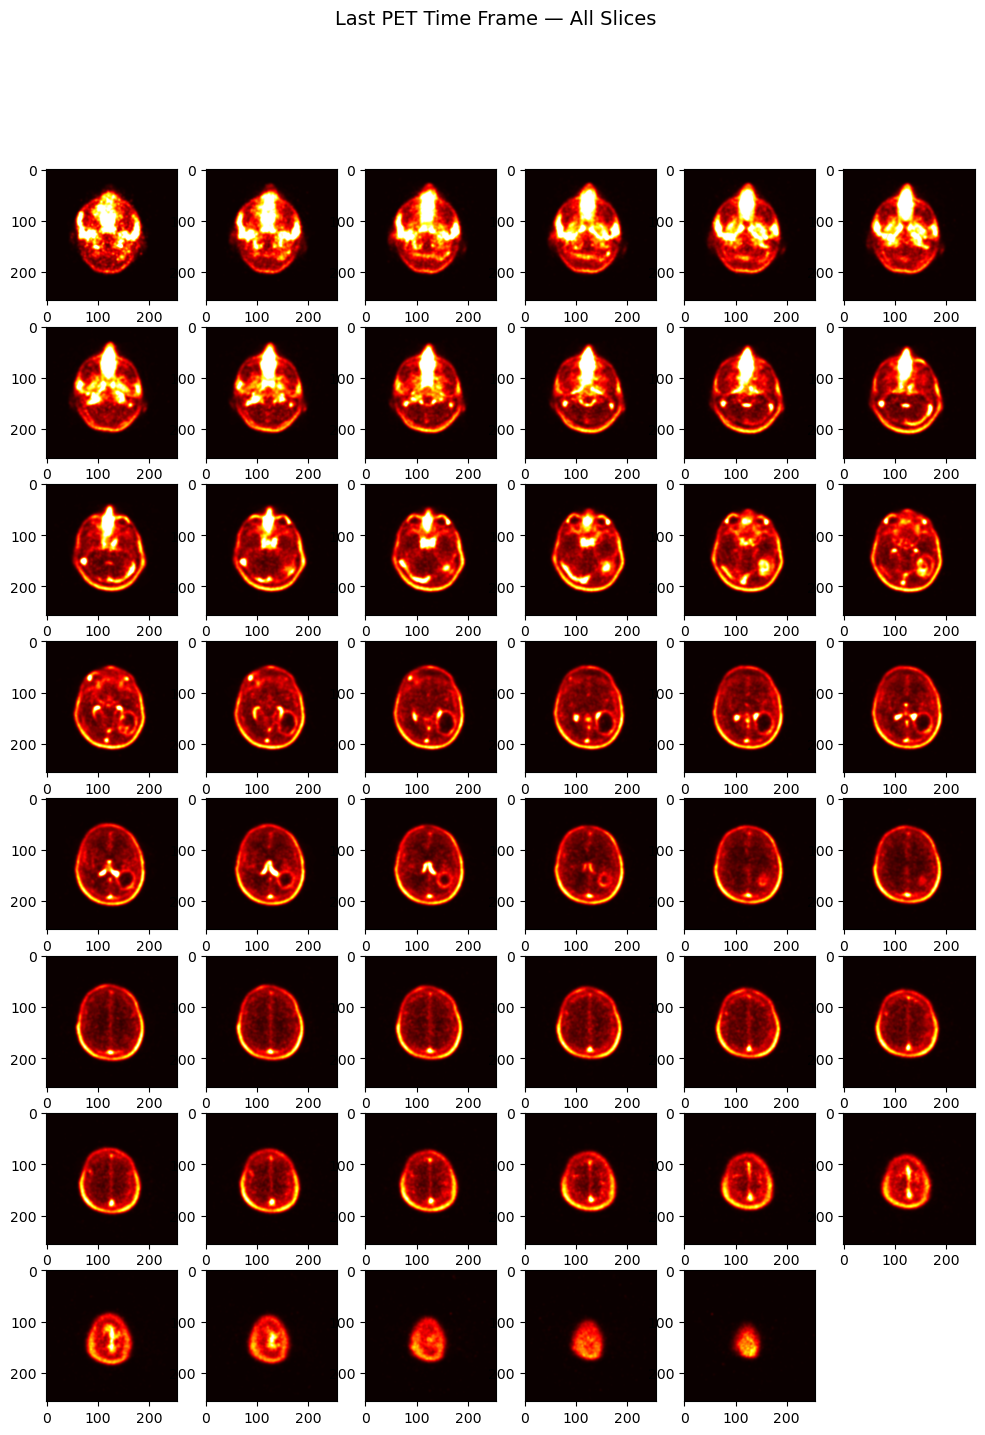

In [33]:
mean_pet = pet4d.mean(axis=0)
print(f'mean_pet shape: {mean_pet.shape}')

vmax = np.percentile(mean_pet, 99)
vmin = 0

n_cols = 6
n_rows = int(np.ceil(n_slices / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2, n_rows * 2))
fig.suptitle('Last PET Time Frame — All Slices', fontsize=14)

for i, ax in enumerate(axes.flat):
    if i < n_slices:
        ax.imshow(mean_pet[i], cmap='hot', vmin=vmin, vmax=vmax)
        pass
    else:
        ax.axis('off')

plt.savefig('./results_task1/mean_frame.png', dpi=100, bbox_inches='tight')
plt.show()

# Task 1E - GIF

## Median Planes

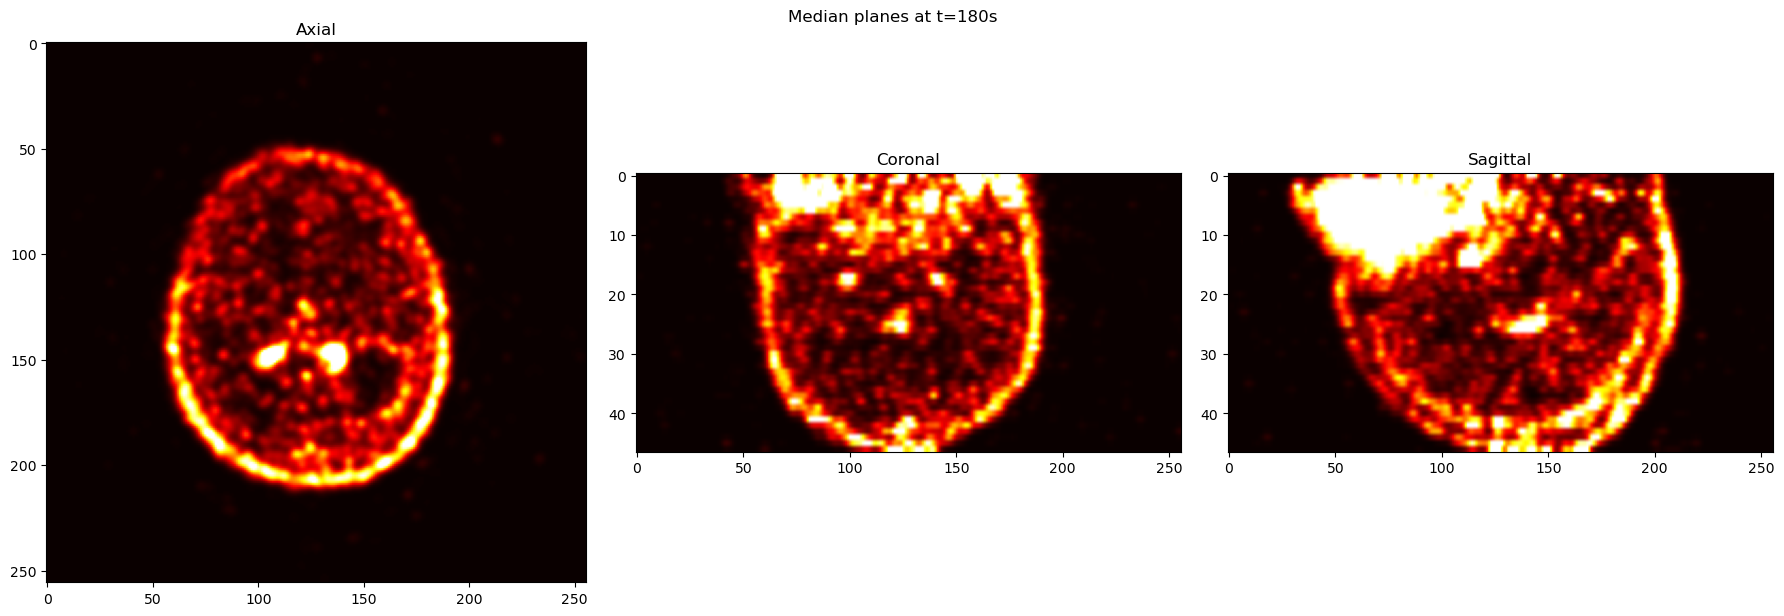

In [34]:
spacing_between_slices = float(pet_ds.SpacingBetweenSlices)
pixel_spacing = float(pet_ds.PixelSpacing[0])
aspect_aniso = spacing_between_slices / pixel_spacing  # for coronal/sagittal

# Extract median planes across all time frames
# YOUR CODE HERE
axial    = pet4d[:, n_slices//2, :,:]  # (36, 256, 256)
coronal  = pet4d[:, :, rows//2,:]
sagittal = pet4d[:,:,:, cols//2]

# Preview: show the middle time frame for each plane
t_mid = n_time // 2
vmax  = np.percentile(pet4d, 99)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(f'Median planes at t={unique_t[t_mid]:.0f}s')

axes[0].imshow(axial[t_mid],    cmap='hot', vmin=0, vmax=vmax, aspect='equal')
axes[0].set_title('Axial')

# YOUR CODE HERE — coronal and sagittal with correct aspect ratio
axes[1].imshow(coronal[t_mid],  cmap='hot', vmin=0, vmax=vmax, aspect=aspect_aniso)
axes[1].set_title('Coronal')

axes[2].imshow(sagittal[t_mid],  cmap='hot', vmin=0, vmax=vmax, aspect=aspect_aniso)
axes[2].set_title('Sagittal')

plt.tight_layout()
plt.show()

## Create and Export GIF

In [36]:
# Global normalization — computed ONCE before the loop
vmax = np.percentile(pet4d, 99)

frames_gif = []

for t in range(n_time):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f't = {unique_t[t]:.0f} s', fontsize=12)


    axes[0].imshow(axial[t], cmap='hot', vmin=0, vmax=vmax, aspect='equal')
    axes[0].set_title(f'Axial at {t} sec')

    axes[1].imshow(coronal[t],  cmap='hot', vmin=0, vmax=vmax, aspect=aspect_aniso)
    axes[1].set_title(f'Coronal at {t} sec')

    axes[2].imshow(sagittal[t],  cmap='hot', vmin=0, vmax=vmax, aspect=aspect_aniso)
    axes[2].set_title(f'Sagittal at {t} sec')

    for ax in axes:
        ax.axis('off')

    plt.tight_layout()

    fig.canvas.draw()
    frame_img = np.asarray(fig.canvas.buffer_rgba())[:, :, :3]  # drop alpha channel
    frames_gif.append(frame_img)
    plt.close(fig)

    if t % 10 == 0:
        print(f'  Rendered frame {t+1}/{n_time}')

imageio.mimsave('./results_task1/median_planes.gif', frames_gif, fps=5)
print('GIF saved to pet_animation.gif')

  Rendered frame 1/36
  Rendered frame 11/36
  Rendered frame 21/36
  Rendered frame 31/36
GIF saved to pet_animation.gif
